<center>
  <h2>Prelims 2024</h2>
  <h3>Mani Tyagi</h3>
  <h4>200973108</h4>
</center>

In [438]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

### Part (1)

To get an idea of the growth model to use, I am first plotting the time series of bacterial growth. Before this I first asked ChatGpt(conversation is attached in the report) about the potential growth models which can be used and under what cases can they be used. The different growth models which are commonly used for bacterial growth are:


- $\textbf{Exponential Growth Model}$:  Appropriate when bacterial growth is in exponential phase.
- $\textbf{Gompertz Growth Model}$: Appropriate when bacterial growth show sigmoidal growth pattern.
- $\textbf{Monod Model}$: Appropriate when growth rate depends on the concentration of a limiting nutrient.
- $\textbf{Logistic Growth Model}$: Appropriate when growth rate has a saturation point.


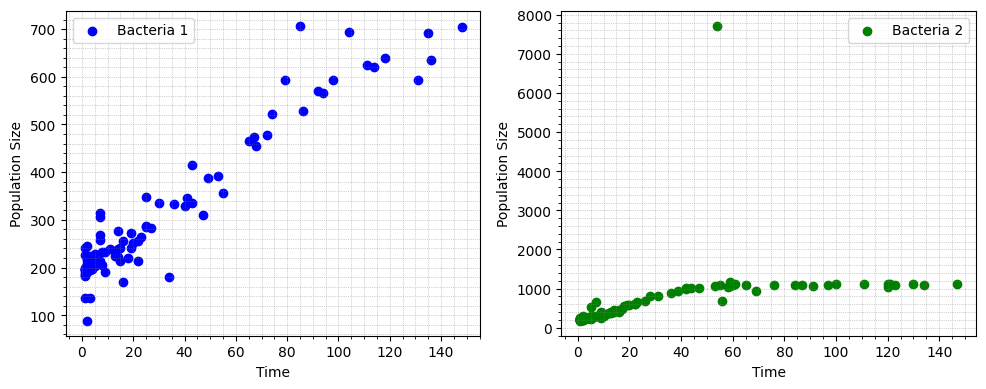

In [439]:
# Read data from files
def read_data(filename):
    data = np.loadtxt(filename)
    return data[:, 0], data[:, 1]

# Read the data for both Bacterias
time1, population1 = read_data('bacteria1.txt')
time2, population2 = read_data('bacteria2.txt')

# Plot the raw data
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(time1, population1, label='Bacteria 1', color='blue')
plt.xlabel('Time')
plt.ylabel('Population Size')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(time2, population2, label='Bacteria 2', color='green')
plt.xlabel('Time')
plt.ylabel('Population Size')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

As shown from the plots above, the data is varying logarithmically and hence Logistic Growth model should be used. Another reason for choosing Logistic Growth model is that the plots for sure doens't show exponential growth behaviour and I am not familiar with the remaining two models. For simplicity, I am taking two parameters only in this model. This was also suggested by ChatGpt.

$$
N(t) = \dfrac{K}{1+\left(\dfrac{k-N_0}{N_0}\right)e^{-rt}}
$$
where:
- $N(t)$ is the population size at time $t$.
- ​$N_0$ is the initial population size.
- $K$ is the carrying capacity (parameter 1).
- $r$ is the intrinsic growth rate (parameter 2).

In [440]:
def logistic_growth(t, K, r, N0=100):
    """-------------------------------------------------------------
    Compute the logistic growth of bacterial population over time.

    Parameters:
    - t  : Time variable.
    - K  : Carrying capacity, maximum population size.
    - r  : Growth rate.
    - N0 : Initial population size. Default is 100.

    Returns:
    - Population size at time t.
    ----------------------------------------------------------------"""
    
    return K / (1 + ((K - N0) / N0) * np.exp(-r * t))


### Part (2)

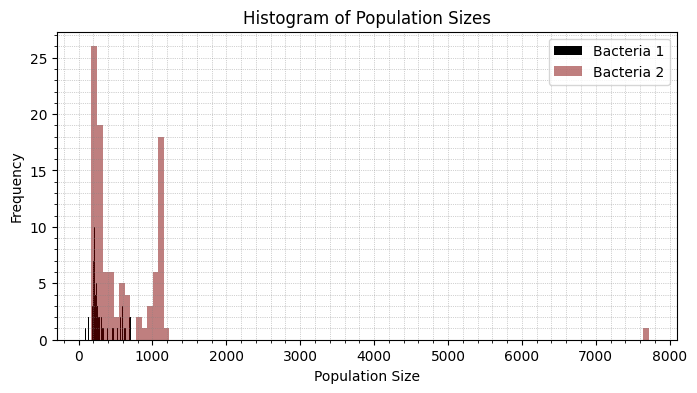

In [441]:
# Plot histograms of the data
plt.figure(figsize=(8, 4))
plt.hist(population1, bins=100, alpha=1, label='Bacteria 1', color='black')
plt.hist(population2, bins=100, alpha=0.5, label='Bacteria 2', color='maroon')
plt.xlabel('Population Size')
plt.ylabel('Frequency')
plt.title('Histogram of Population Sizes')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.legend()
plt.show()

As clear from the histogram plot above, the growth of bacteria 2 is more spread out and has higher population size compared to bacteria 1 which is having population size at a narrower range. One more interesting point is the sudden jump in population of bacteria 2 at $t = 54$. The population suddenly becomes around 7000 which is also shown in the histogram. 

### Part (3)

### Metropolis Hastings

The Metropolis-Hastings algorithm is a Markov Chain Monte Carlo (MCMC) method used for sampling from probability distributions. It is particularly useful when direct sampling from the distribution is difficult. The algorithm constructs a Markov chain that converges to the desired distribution, with the stationary distribution of the chain being the target distribution. At each iteration, it generates a proposal state based on the current state and accepts or rejects the proposal based on a specific acceptance criterion. Over iterations, the algorithm produces samples from the target distribution. 

In [442]:
def log_likelihood(K, r, t, population):
    """
    -----------------------------------------------------------------------------------
    Calculate the log likelihood of the observed population given the parameters 
    K and r of the logistic growth model.

    Parameters:
    - K : Carrying capacity, maximum population size.
    - r : Growth rate.
    - t : Time variable.
    - population : Observed population sizes corresponding to the time points t.

    Returns:
    - Log likelihood of the observed population.
    -------------------------------------------------------------------------------------
    """
    predicted = logistic_growth(t, K, r)
    return -0.5 * np.sum((population - predicted) ** 2)


def proposal(param, scale=[0.1, 0.01]):
    """
    ---------------------------------------------------------------------------------
    Generate a proposal parameter vector based on the current parameter values.

    Parameters:
    - param : Current parameter values.
    - scale : Scaling factors for each parameter. Default is set to [0.1, 0.01].

    Returns:
    - list: Proposed parameter values.
    ---------------------------------------------------------------------------------
    """
    return [param[i] + scale[i] * np.random.randn() for i in range(len(param))]



def metropolis_hastings(t, population, iterations=1000000, iter_discard=10000):
    """
    --------------------------------------------------------------------------------------------
    Perform Metropolis-Hastings MCMC sampling to estimate parameters K and r 
    of the logistic growth model.

    Parameters:
    - t : Time variable.
    - population : Observed population sizes corresponding to the time points t.
    - iterations : Total number of MCMC iterations. Default is 100000.
    - iter_discard : Number of iterations to discard as the solution is unstable initially.

    Returns:
    - numpy.ndarray: Array of sampled parameter values (excluding burn-in).
    --------------------------------------------------------------------------------------------
    """
    K_current, r_current = 1000, 0.1
    log_likelihood_current = log_likelihood(K_current, r_current, t, population)
    
    MCMC = []
    accepted = 0
    
    for _ in range(iterations):
        K_proposal, r_proposal = proposal([K_current, r_current])
        if K_proposal <= 0 or r_proposal <= 0:
            continue
        
        log_likelihood_proposal = log_likelihood(K_proposal, r_proposal, t, population)
        log_acceptance_ratio = log_likelihood_proposal - log_likelihood_current
        
        if log_acceptance_ratio > 0 or np.log(np.random.rand()) < log_acceptance_ratio:
            K_current, r_current = K_proposal, r_proposal
            log_likelihood_current = log_likelihood_proposal
            accepted += 1
            
        MCMC.append([K_current, r_current])
    
    MCMC = np.array(MCMC[iter_discard:])
    return MCMC

In [443]:
# Run MCMC for both Bacterias
MCMC1 = metropolis_hastings(time1, population1)
MCMC2 = metropolis_hastings(time2, population2)

# Print parameters for both MCMC
print("-"*30)
print("Parameters for Bacteria 1:")
print("-"*30)
print("Mean K:", np.mean(MCMC1[:, 0]))
print("Mean r:", np.mean(MCMC1[:, 1]))
print("Final K:", MCMC1[-1, 0])
print("Final r:", MCMC1[-1, 1])

print("\n")
print("-"*30)
print("Parameters for Bacteria 2:")
print("-"*30)
print("Mean K:", np.mean(MCMC2[:, 0]))
print("Mean r:", np.mean(MCMC2[:, 1]))
print("Final K:", MCMC2[-1, 0])
print("Final r:", MCMC2[-1, 1])

------------------------------
Parameters for Bacteria 1:
------------------------------
Mean K: 740.635076632971
Mean r: 0.041418087653550005
Final K: 626.5084346930691
Final r: 0.049222993499177116


------------------------------
Parameters for Bacteria 2:
------------------------------
Mean K: 1279.1786095887194
Mean r: 0.1197049948309464
Final K: 1284.8533881381127
Final r: 0.1193281096824759


#### Posterior statistics

I varied my initial parameters and iterations in my Metropolis Hastings function until I got results in the credible intervals. For confidence interval of 95\%, I got the following results with 1000000 iterations in the algorithm. For the remaining question I used k = 1000 and r = 0.1 as initial guess of my parameters.

In [444]:
# Extract samples of K and r for Bacteria 1
K_samples = MCMC1[:, 0]
r_samples = MCMC1[:, 1]

# Calculate posterior statistics
K_mean = np.mean(K_samples)
r_mean = np.mean(r_samples)
K_std = np.std(K_samples)
r_std = np.std(r_samples)

# Define credible intervals of 95% i.e. alpha = 0.05
credible_interval_K = np.percentile(K_samples, [2.5, 97.5])
credible_interval_r = np.percentile(r_samples, [2.5, 97.5])

print("Posterior Summary Statistics:")
print("-"*80)
print("Bacteria 1:")
print("K: Mean = {:.2f}, Std = {:.2f}, Credible Interval = [{:.2f}, {:.2f}]".format(K_mean, K_std, credible_interval_K[0], credible_interval_K[1]))
print("r: Mean = {:.2f}, Std = {:.2f}, Credible Interval = [{:.2f}, {:.2f}]".format(r_mean, r_std, credible_interval_r[0], credible_interval_r[1]))


# Extract samples of K and r for Bacteria 2
K_samples = MCMC2[:, 0]
r_samples = MCMC2[:, 1]

# Calculate posterior statistics
K_mean = np.mean(K_samples)
r_mean = np.mean(r_samples)
K_std = np.std(K_samples)
r_std = np.std(r_samples)

# Define credible intervals of 95% i.e. alpha = 0.05
credible_interval_K = np.percentile(K_samples, [2.5, 97.5])
credible_interval_r = np.percentile(r_samples, [2.5, 97.5])

print("-"*80)
print("Bacteria 1:")
print("K: Mean = {:.4f}, Std = {:.4f}, Credible Interval = [{:.4f}, {:.4f}]".format(K_mean, K_std, credible_interval_K[0], credible_interval_K[1]))
print("r: Mean = {:.4f}, Std = {:.4f}, Credible Interval = [{:.4f}, {:.4f}]".format(r_mean, r_std, credible_interval_r[0], credible_interval_r[1]))
print("-"*80)


Posterior Summary Statistics:
--------------------------------------------------------------------------------
Bacteria 1:
K: Mean = 740.64, Std = 133.05, Credible Interval = [626.15, 985.07]
r: Mean = 0.04, Std = 0.01, Credible Interval = [0.03, 0.05]
--------------------------------------------------------------------------------
Bacteria 1:
K: Mean = 1279.1786, Std = 27.0274, Credible Interval = [1181.4383, 1285.6450]
r: Mean = 0.1197, Std = 0.0019, Credible Interval = [0.1192, 0.1264]
--------------------------------------------------------------------------------


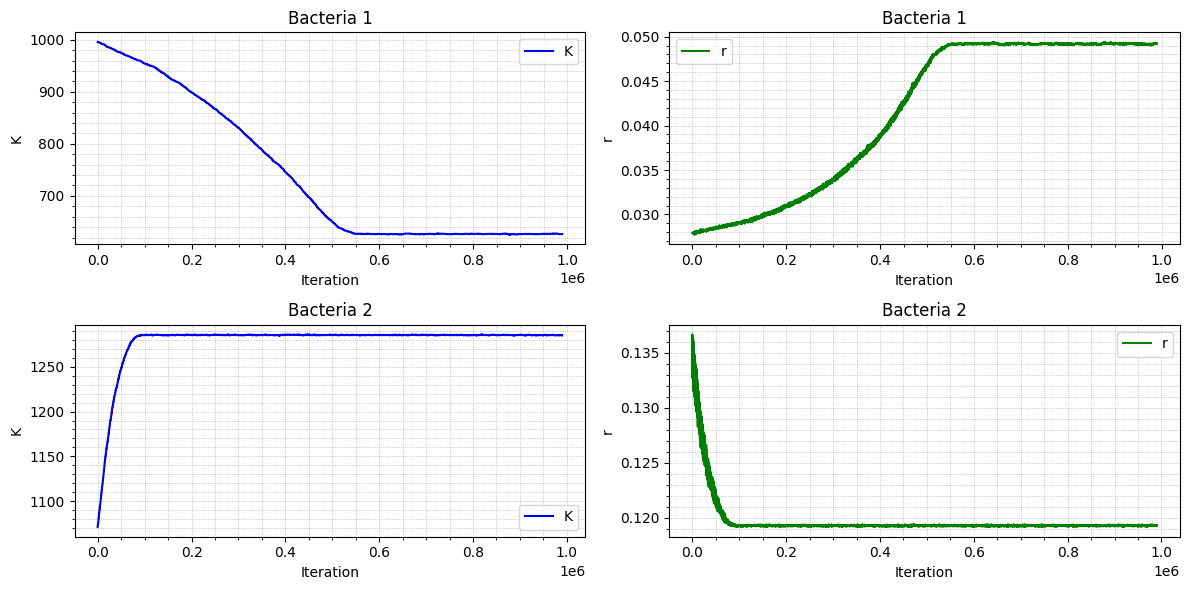

In [445]:
# Data for plotting
trace_data = [
    (MCMC1[:, 0], 'K', 'Bacteria 1', 'blue'),
    (MCMC1[:, 1], 'r', 'Bacteria 1', 'green'),
    (MCMC2[:, 0], 'K', 'Bacteria 2', 'blue'),
    (MCMC2[:, 1], 'r', 'Bacteria 2', 'green')
]

plt.figure(figsize=(12, 6))

for i, (data, label, title, color) in enumerate(trace_data):
    plt.subplot(2, 2, i+1)
    plt.plot(data, label=label, color=color)
    plt.xlabel('Iteration')
    plt.ylabel(label)
    plt.minorticks_on()
    plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
    plt.title(title)
    plt.legend()

plt.tight_layout()
plt.show()


Once, I got the final parameters within credible intervals, I plotted the results with raw data. Following are the results I am getting. They are within the credible intervals defined. The figure above shows the evolution of k and r for $10^6$ iterations. For calculation of final statistics first $10^3$ iterations are discarded.

In [468]:
# general function for plotting the three methods used: MCMC, PSO, EM
# MCMC - Metropolis-Hastings
# PSO - Particle Swarm optimisation
# EM - Expectation-Minimization 

def plot_logistic_growth(ax, t, population, K, r, i=0, j=0):
    if i == 1:  # plot PSO
        color_plot = 'green'
        label_plot = 'Particle Swarm'
        linestyles = None
        lws = 2 
    
    elif i == 2: # Plot EM
        color_plot = 'blue'
        label_plot = 'E-M'
        linestyles = None       
        lws = 2 
        
        
    else: # plot MCMC
        color_plot = 'maroon'
        label_plot = 'MCMC'
        linestyles = '--'
        lws = 4 

    
    if j == 0: # wheter to print original data or not
        ax.plot(t, population, color='black', marker='.', linestyle='', label='Original Data')    
                
    ax.plot(t, logistic_growth(t, K, r), color=color_plot, lw=lws, linestyle=linestyles, label=label_plot)
    ax.set_xlabel('Time')
    ax.set_ylabel('Population')
    ax.minorticks_on()
    ax.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
    ax.legend()

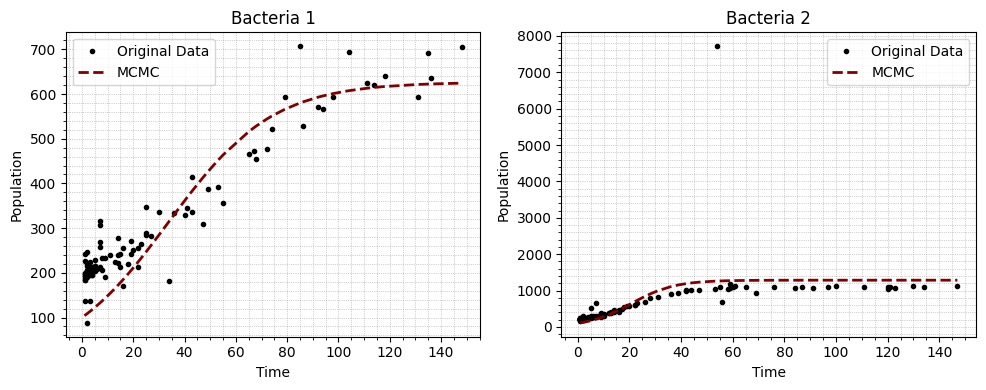

In [464]:
# Plot comparison for Bacteria 1 
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_logistic_growth(plt.gca(), time1, population1, MCMC1[-1, 0], MCMC1[-1, 1])
plt.title('Bacteria 1')

# Plot comparison for Bacteria 2 
plt.subplot(1, 2, 2)
plot_logistic_growth(plt.gca(), time2, population2, MCMC2[-1, 0], MCMC2[-1, 1])

plt.title('Bacteria 2')

plt.tight_layout()
plt.show()


### Part (4)

### Particle Swarm Optimization

Particle Swarm Optimization (PSO) is a population-based stochastic optimization technique inspired by the social behavior of birds flocking or fish schooling. Each particle in the swarm represents a potential solution and adjusts its position based on its own experience and the experience of neighboring particles. The velocity and position of each particle are updated using the following equations:

\begin{align*}
v_{i}(t+1) &= w v_{i}(t) + c_1 r_1 (p_{i} - x_{i}(t)) + c_2 r_2 (g - x_{i}(t)) \\
x_{i}(t+1) &= x_{i}(t) + v_{i}(t+1)
\end{align*}

where $v_{i}$ is the velocity, $x_{i}$ is the position, $p_{i}$ is the personal best position, $g$ is the global best position, $w$ is the inertia weight, $c_1$ and $c_2$ are cognitive and social parameters, and $r_1$ and $r_2$ are random numbers in $[0, 1]$.


$\textbf{Applying Particle Swarm Optimization to Bacterial Growth Modeling}$

Particle Swarm Optimization (PSO) can be effectively used to fit bacterial growth models by optimizing the parameters of the growth function to best match observed data. The logistic growth model, often used to describe bacterial population dynamics, can be parameterized by carrying capacity $K$ and growth rate $r$. The PSO algorithm seeks to minimize the mean squared error (MSE) between observed population data and the predicted values from the logistic growth model.

The optimization process involves:
- Initializing a swarm of particles, each representing potential values for $K$ and $r$.
- Iteratively updating the velocity $v_i$ and position $x_i$ of each particle using:
    $$
    v_{i}(t+1) = w v_{i}(t) + c_1 r_1 (p_{i} - x_{i}(t)) + c_2 r_2 (g - x_{i}(t)) \\
    x_{i}(t+1) = x_{i}(t) + v_{i}(t+1)
    $$
    
- Evaluating the fitness of each particle based on the MSE between observed and predicted populations.
- Updating personal and global best positions based on fitness values.

By iteratively refining the parameters, PSO converges to an optimal or near-optimal solution, providing the best-fit parameters $K$ and $r$ for the bacterial growth model.


In [470]:
def fitness_function(params, t, population):
    """---------------------------------------------------------------------------------------
    Compute the mean squared error (MSE) between the observed population and the 
    predicted population based on the logistic growth model.

    Parameters:
    - params     : Parameters (K, r) of the logistic growth model.
    - t          : Time variable.
    - population : Observed population sizes corresponding to the time points t.

    Returns:
    -  Mean squared error between the observed and predicted populations.
    -------------------------------------------------------------------------------------------"""
    
    K, r = params
    predicted_population = logistic_growth(t, K, r)
    mse = np.mean((population - predicted_population) ** 2)
    return mse

# Particle Swarm Optimization (PSO) algorithm
def particle_swarm_optimization(t, population, num_particles=30, max_iter=10000, w=0.5, c1=1, c2=2):
    """
    -----------------------------------------------------------------------------------------------
    Perform Particle Swarm Optimization (PSO) to find the optimal parameters (K, r) 
    of the logistic growth model.

    Parameters:
    - t : Time variable.
    - population : Observed population sizes corresponding to the time points t.
    - num_particles : Number of particles in the swarm. Default is 30.
    - max_iter : Maximum number of iterations. Default is 10000.
    - w : Inertia weight. Default is 0.5.
    - c1 : Cognitive parameter. Default is 1.
    - c2 : Social parameter. Default is 2.

    Returns:
    - array-like: Optimal parameters (K, r) of the logistic growth model.
    -----------------------------------------------------------------------------------------------
    """
    
    # Initialize the swarm
    swarm = np.random.rand(num_particles, 2) * [1000, 0.1]
    velocities = np.random.randn(num_particles, 2)
    personal_best_positions = np.copy(swarm)
    personal_best_scores = np.array([fitness_function(p, t, population) for p in swarm])
    global_best_position = personal_best_positions[np.argmin(personal_best_scores)]
    global_best_score = np.min(personal_best_scores)

    for i in range(max_iter):
        for j in range(num_particles):
            # Update velocity
            velocities[j] = (w * velocities[j] +
                             c1 * np.random.rand() * (personal_best_positions[j] - swarm[j]) +
                             c2 * np.random.rand() * (global_best_position - swarm[j]))

            # Update position
            swarm[j] = swarm[j] + velocities[j]

            # Update personal best
            score = fitness_function(swarm[j], t, population)
            if score < personal_best_scores[j]:
                personal_best_scores[j] = score
                personal_best_positions[j] = np.copy(swarm[j])

        # Update global best
        current_global_best_score = np.min(personal_best_scores)
        if current_global_best_score < global_best_score:
            global_best_score = current_global_best_score
            global_best_position = personal_best_positions[np.argmin(personal_best_scores)]

    return global_best_position


Final K and r values for Bacteria 1:
K: 626.7679917437007
r: 0.04919636782007289

Final K and r values for Bacteria 2:
K: 1285.2988120403209
r: 0.11928224121764017


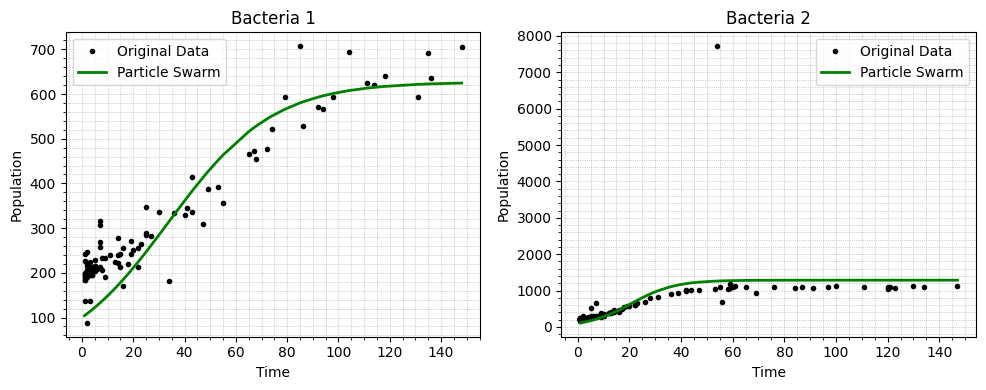

In [466]:
# Perform PSO algorithm for both Bacterias
PSO1 = particle_swarm_optimization(time1, population1)
PSO2 = particle_swarm_optimization(time2, population2)

# Print the final K and r values
print("Final K and r values for Bacteria 1:")
print("K:", PSO1[0])
print("r:", PSO1[1])

print("\nFinal K and r values for Bacteria 2:")
print("K:", PSO2[0])
print("r:", PSO2[1])

# Plot comparison for Bacteria 1 
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_logistic_growth(plt.gca(), time1, population1, PSO1[0], PSO1[1], 1, 0)
plt.title('Bacteria 1')

# Plot comparison for Bacteria 2 
plt.subplot(1, 2, 2)
plot_logistic_growth(plt.gca(), time2, population2, PSO2[0], PSO2[1], 1, 0)

plt.title('Bacteria 2')

plt.tight_layout()
plt.show()

### Expectation Minimization

In [458]:
# Expectation step: compute expected values of the latent variable
def expectation_step(t, population, K, r):
    predicted = logistic_growth(t, K, r)
    return predicted

# Maximization step: update parameters based on expected values
def maximization_step(t, population, expected_population, K, r):
    epsilon = 1e-10  # Small value to avoid division by zero
    
    numerator_K = np.sum(expected_population)
    denominator_K = np.sum(1 - np.exp(-r * t))
    K_new = numerator_K / (denominator_K + epsilon)

    numerator_r = np.sum((population - expected_population) * t * np.exp(-r * t))
    denominator_r = np.sum(expected_population * t ** 2 * np.exp(-r * t))
    
    if np.abs(denominator_r) < epsilon:
        r_new = r
    else:
        r_new = numerator_r / (denominator_r + epsilon)

    return K_new, r_new

# EM algorithm with tracking of parameter values
def expectation_maximization(t, population, iterations=1000, tol=1e-12):
    # Initialize parameters
    K, r = 100, 0.1
    K_values, r_values = [K], [r]
    
    for i in range(iterations):
        # Expectation step
        expected_population = expectation_step(t, population, K, r)
        
        # Maximization step
        K_new, r_new = maximization_step(t, population, expected_population, K, r)
        
        # Append K and r values to the lists
        K_values.append(K_new)
        r_values.append(r_new)
        
        # Check for convergence
        if np.abs(K_new - K) < tol and np.abs(r_new - r) < tol:
            print(f'Converged in {i+1} iterations.')
            break
        
        K, r = K_new, r_new
    
    return K_values, r_values

In [459]:
# Perform EM algorithm with tracking for both Bacterias
EM1_k, EM1_r = expectation_maximization(time1, population1)
print("Final K and r values for Bacteria 1:")
print("K:", EM1_k[-1])
print("r:", EM1_r[-1])

print('\n')
EM2_k, EM2_r = expectation_maximization(time2, population2)
print("Final K and r values for Bacteria 2:")
print("K:", EM2_k[-1])
print("r:", EM2_r[-1])

Converged in 172 iterations.
Final K and r values for Bacteria 1:
K: 527.503808325866
r: 0.016207137612757973


Converged in 98 iterations.
Final K and r values for Bacteria 2:
K: 401.8597663844109
r: 0.07674958055485223


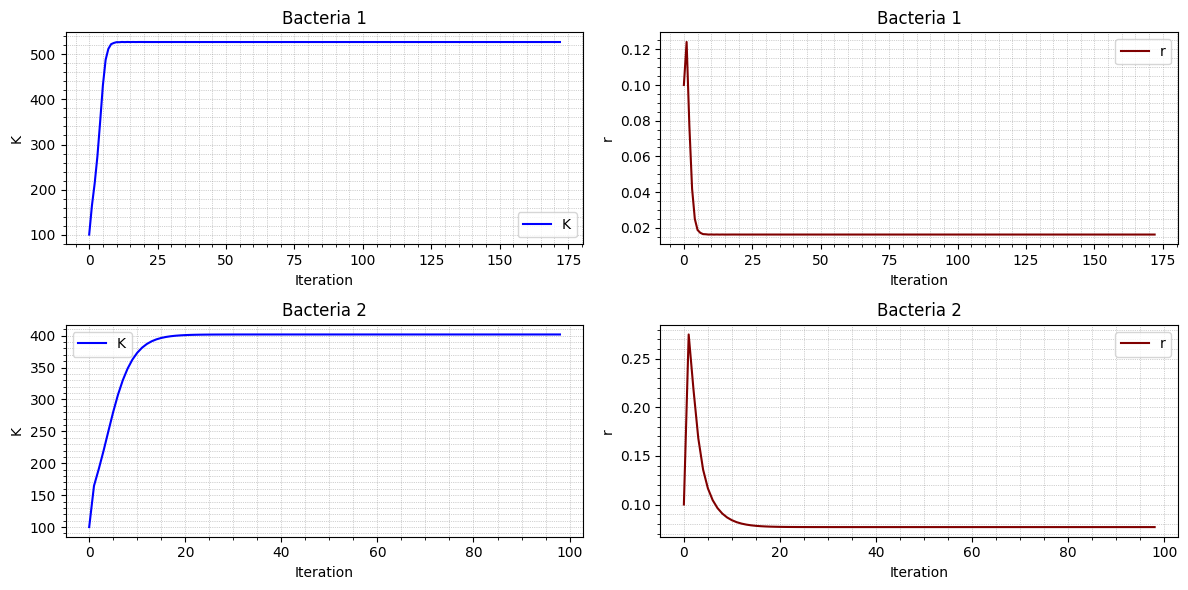

In [452]:
# Data for plotting
trace_data = [
    (EM1_k, 'K', 'Bacteria 1', 'blue'),
    (EM1_r, 'r', 'Bacteria 1', 'maroon'),
    (EM2_k, 'K', 'Bacteria 2', 'blue'),
    (EM2_r, 'r', 'Bacteria 2', 'maroon')
]

plt.figure(figsize=(12, 6))

for i, (data, label, title, color) in enumerate(trace_data):
    plt.subplot(2, 2, i+1)
    plt.plot(range(len(data)), data, label=label, color=color)
    plt.xlabel('Iteration')
    plt.ylabel(label)
    plt.minorticks_on()
    plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
    plt.title(title)
    plt.legend()

plt.tight_layout()
plt.show()


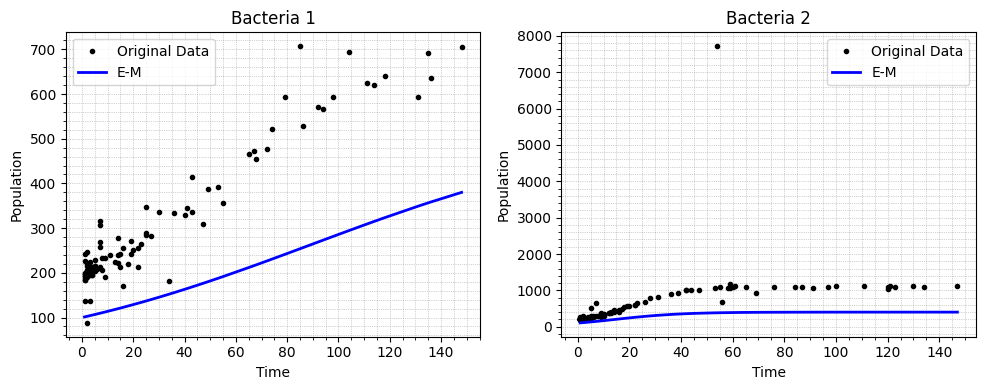

In [453]:
# Plot comparison
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_logistic_growth(plt.gca(), time1, population1, EM1_k[-1], EM1_r[-1], 2)
plt.title('Bacteria 1')

plt.subplot(1, 2, 2)
plot_logistic_growth(plt.gca(), time2, population2, EM2_k[-1], EM2_r[-1], 2)

plt.title('Bacteria 2')

plt.tight_layout()
plt.show()


### Part (5)

#### Comarison of Results

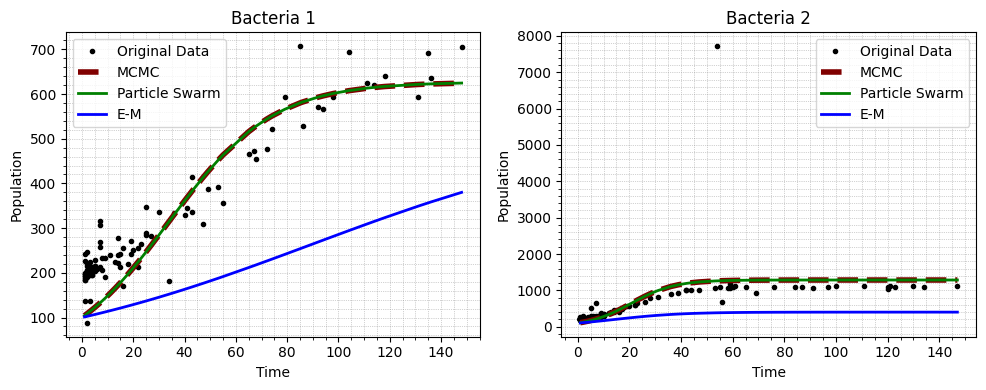

In [469]:
# Plot comparison
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_logistic_growth(plt.gca(), time1, population1, MCMC1[-1, 0], MCMC1[-1, 1], 0)
plot_logistic_growth(plt.gca(), time1, population1, PSO1[0], PSO1[1], 1, 1)
plot_logistic_growth(plt.gca(), time1, population1, EM1_k[-1], EM1_r[-1], 2, 1)
plt.title('Bacteria 1')

# Plot comparison for Bacteria 2
plt.subplot(1, 2, 2)
plot_logistic_growth(plt.gca(), time2, population2, MCMC2[-1, 0], MCMC2[-1, 1], 0)
plot_logistic_growth(plt.gca(), time2, population2, PSO2[0], PSO2[1], 1, 1)
plot_logistic_growth(plt.gca(), time2, population2, EM2_k[-1], EM2_r[-1], 2, 1)
plt.title('Bacteria 2')

plt.tight_layout()
plt.show()


The parameters estimated using Particle swarm optimization and Metropolis-Hastings are almost same suggesting that the model works well. Also, these parameters lie within the support interval. They fit the model very well which can be observed from the figures above. However, there is some issue with Expectation minimization method and it is not able to generate good results.

Following is the code to tabulate the results for three methods.

In [455]:
# Final parameter values for Bacteria 1 and 2 from MCMC 
final_K1_mcmc = MCMC1[-1, 0]
final_r1_mcmc = MCMC1[-1, 1]
final_K2_mcmc = MCMC2[-1, 0]
final_r2_mcmc = MCMC2[-1, 1]

# Final parameter values for Bacteria 1 and 2 from EM 
final_K1_em = EM1_k[-1]
final_r1_em = EM1_r[-1]
final_K2_em = EM2_k[-1]
final_r2_em = EM2_r[-1]

# Final parameter values for Bacteria 1 and 2 from PSO
final_K1_PSO = PSO1[0]
final_r1_PSO = PSO1[1]
final_K2_PSO = PSO2[0]
final_r2_PSO = PSO2[1]

# Print header for Bacteria 1
print("="*70)
print("                            Bacteria 1")
print("="*70)
print(f"{'Parameter':<12} {'MCMC':<20} {'PSO':<20} {'EM':<20}")
print("-"*70)

# Print results for Bacteria 1
print(f"{'K':<12} {final_K1_mcmc:<20.2f} {final_K1_PSO:<20.2f} {final_K1_em:<20.2f}")
print(f"{'r':<12} {final_r1_mcmc:<20.2f} {final_r1_PSO:<20.2f} {final_r1_em:<20.2f}")
print("="*70)

print("\n")
# Print header for Bacteria 2
print("="*70)
print("                            Bacteria 2")
print("="*70)
print(f"{'Parameter':<12} {'MCMC':<20} {'PSO':<20} {'EM':<20}")
print("-"*70)

# Print results for Bacteria 2
print(f"{'K':<12} {final_K2_mcmc:<20.2f} {final_K2_PSO:<20.2f} {final_K2_em:<20.2f}")
print(f"{'r':<12} {final_r2_mcmc:<20.2f} {final_r2_PSO:<20.2f} {final_r2_em:<20.2f}")
print("="*70)


                            Bacteria 1
Parameter    MCMC                 PSO                  EM                  
----------------------------------------------------------------------
K            626.51               626.77               527.50              
r            0.05                 0.05                 0.02                


                            Bacteria 2
Parameter    MCMC                 PSO                  EM                  
----------------------------------------------------------------------
K            1284.85              1285.30              401.86              
r            0.12                 0.12                 0.08                
